In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes
X,y = load_diabetes(return_X_y=True)
from sklearn.linear_model import LinearRegression
mod = LinearRegression()
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression)
])

In [2]:
mod.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [3]:
pred = mod.predict(X)

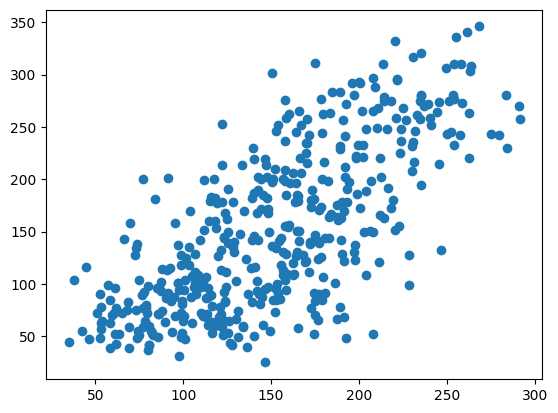

In [6]:
plt.scatter(pred,y)

In [7]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.drop(columns=['SkinThickness', 'Insulin', 'Pregnancies', 'BloodPressure', 'DiabetesPedigreeFunction', 'Age'], inplace=True)
df.head()

,Glucose,BMI,Outcome
0,148,33.6,1
1,85,26.6,0
2,183,23.3,1
3,89,28.1,0
4,137,43.1,1


In [9]:
x = df[['Glucose', 'BMI']].values
y = df['Outcome'] 

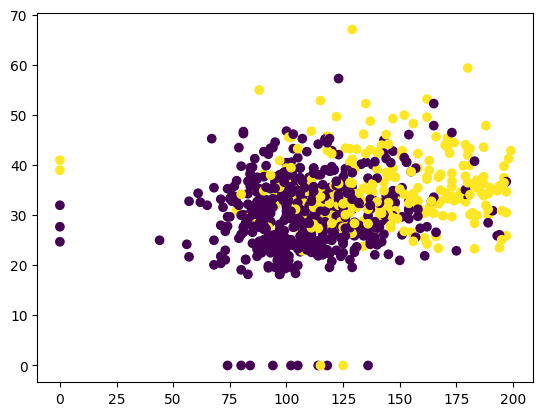

In [10]:
plt.scatter(x[:,0], x[:,1], c=y)

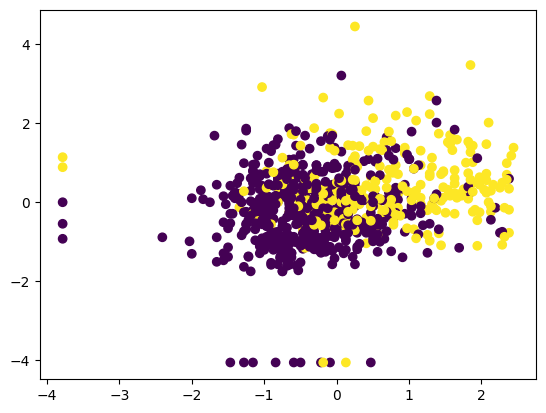

In [11]:
from sklearn.preprocessing import StandardScaler
x_new = StandardScaler().fit_transform(x)
plt.scatter(x_new[:,0], x_new[:,1], c=y);  # <-- semicolon

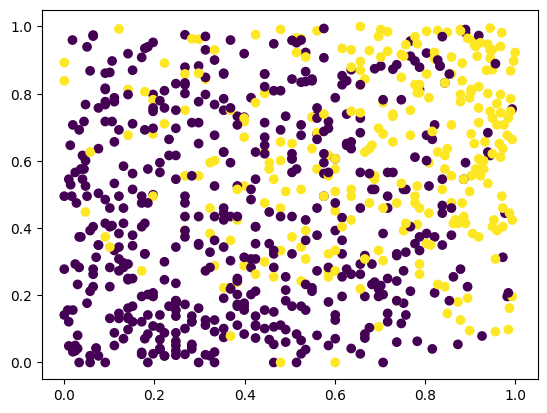

In [12]:
from sklearn.preprocessing import QuantileTransformer
x_new = QuantileTransformer(n_quantiles= 100).fit_transform(x)
plt.scatter(x_new[:,0], x_new[:,1], c=y);  

In [11]:
def plot_output(scaler):
    pipe = Pipeline([
        ("scale", scaler),
        ("model", KNeighborsClassifier(n_neighbors=20, weights='distance'))
    ])

    pred = pipe.fit(X, y).predict(X)

    plt.figure(figsize=(9, 3))
    plt.subplot(131)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Original Data")
    plt.subplot(132)
    X_tfm = scaler.transform(X)
    plt.scatter(X_tfm[:, 0], X_tfm[:, 1], c=y)
    plt.title("Transformed Data")
    plt.subplot(133)
    X_new = np.concatenate([
        np.random.uniform(0, X[:, 0].max(), (5000, 1)), 
        np.random.uniform(0, X[:, 1].max(), (5000, 1))
    ], axis=1)
    y_proba = pipe.predict_proba(X_new)
    plt.scatter(X_new[:, 0], X_new[:, 1], c=y_proba[:, 1], alpha=0.7)
    plt.title("Predicted Data")

In [17]:
!python -m pip install drawdata

  Using cached drawdata-0.3.9-py3-none-any.whl.metadata (2.9 kB)
  Using cached anywidget-0.9.21-py3-none-any.whl.metadata (8.9 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
Using cached drawdata-0.3.9-py3-none-any.whl (238 kB)
Using cached anywidget-0.9.21-py3-none-any.whl (231 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)

   ---------------------------------------- 0/3 [ipywidgets]
   ---------------------------------------- 0/3 [ipywidgets]
   ---------------------------------------- 0/3 [ipywidgets]
   ---------------------------------------- 0/3 [ipywidgets]
   ---------------------------------------- 0/3 [ipywidgets]
   ---------------------------------------- 0/3 [ipywidgets]
   ---------------------------------------- 0/3 [ipywidgets]
   ---------------------------------------- 0/3 [ipywidgets]
   ------------- -------------------------- 1/3 [anywidget]
   ---------------------------------------- 3/3 [drawdata]



In [8]:
from drawdata import ScatterWidget
widget = ScatterWidget()
widget

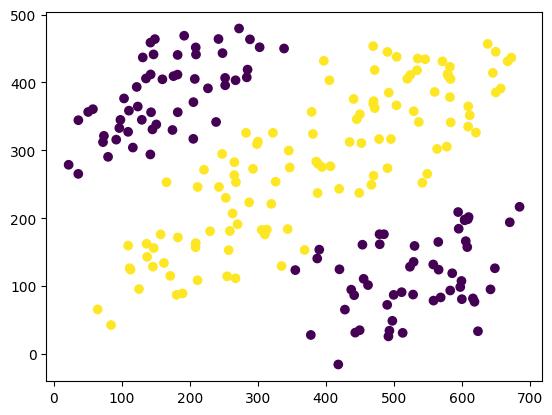

In [13]:
df = pd.read_csv("drawndata2.csv")
X = df[['x', 'y']].values
y = df['z'] == 'a'
plt.scatter(X[:, 0], X[:, 1], c=y);

In [10]:
df.head()

,x,y,z
0,469.759355,453.574946,a
1,535.331819,435.221848,a
2,504.285526,437.767578,a
3,469.891398,368.371652,a
4,405.425622,403.141546,a


This does not Works

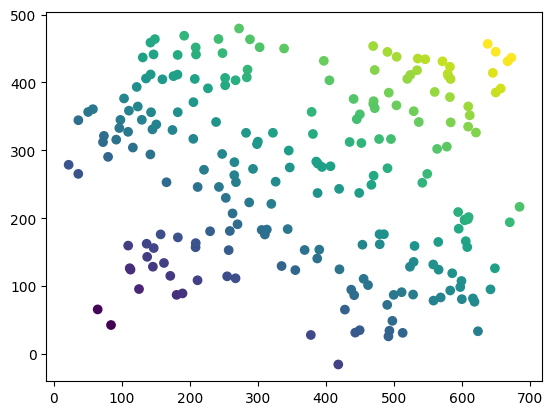

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", LinearRegression())
])

pred = pipe.fit(X, y).predict(X)
plt.scatter(X[:, 0], X[:, 1], c=pred);

Right way is to use Logistic Regression and polynomial features which is use of xy, x2, y2..

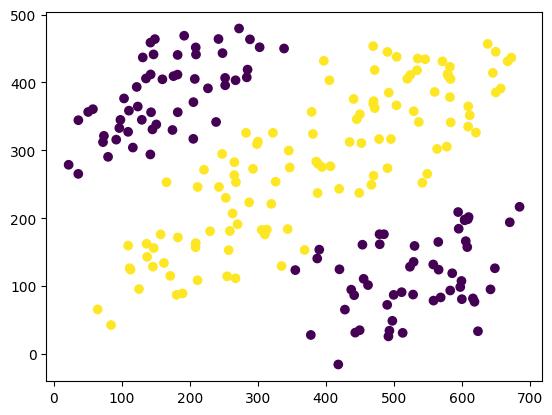

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scale", PolynomialFeatures()),
    ("model", LogisticRegression())
])

pred = pipe.fit(X, y).predict(X)
plt.scatter(X[:, 0], X[:, 1], c=pred);

There is cheating here as data used to fit and predict is the same

In [16]:
arr = np.array(["low", "low", "high", "medium"]).reshape(-1, 1)
arr

array([['low'],
       ['low'],
       ['high'],
       ['medium']], dtype='<U6')

In [18]:
from sklearn.preprocessing import OneHotEncoder

In [24]:
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc.fit_transform(arr)

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

This handle unknown is useful for X not Y

In [25]:
enc.transform([["zero"]])

array([[0., 0., 0.]])